In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)

In [2]:
YEAR_START = 2023
YEAR_END = 2024
PATH_PARQUET = "data/2023-2025_integrated_data_train.parquet"

In [3]:
train_df = pq.read_table(PATH_PARQUET, filters=[
            ("time", ">=", pd.Timestamp(f"{YEAR_START}-01-01")),
            ("time", "<=", pd.Timestamp(f"{YEAR_END}-12-31")),
        ],).to_pandas()
train_df

,site_id,direction,year,month,day,hour,lat_flow,lon,total_count,obs_per_hour,...,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description
0,1,in,2023,1,1,0,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
1,1,in,2023,1,1,1,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
2,1,in,2023,1,1,2,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
3,1,in,2023,1,1,3,50.916183,4.456122,2.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
4,1,in,2023,1,1,4,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4766741,143,out,2024,12,30,20,50.830662,3.262860,47.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
4766742,143,out,2024,12,30,21,50.830662,3.262860,43.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
4766743,143,out,2024,12,30,22,50.830662,3.262860,85.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
4766744,143,out,2024,12,30,23,50.830662,3.262860,48.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4766746 entries, 0 to 4766745
Data columns (total 37 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   site_id                   int32         
 1   direction                 str           
 2   year                      int16         
 3   month                     int8          
 4   day                       int8          
 5   hour                      int8          
 6   lat_flow                  float32       
 7   lon                       float32       
 8   total_count               float32       
 9   obs_per_hour              int64         
 10  time                      datetime64[us]
 11  temperature_2m            float64       
 12  apparent_temperature      float64       
 13  relative_humidity_2m      float64       
 14  precipitation             float64       
 15  rain                      float64       
 16  snowfall                  float64       
 17  wind_speed_10m     

In [5]:
train_df["time"] = pd.to_datetime(train_df["time"])
train_df.set_index("time", inplace=True)

In [6]:
train_df[["site_id", "naam", "domein", "direction"]].head()

,site_id,naam,domein,direction
time,,,,
2023-01-01 00:00:00,1,Machelen,Vlaamse Overheid A. Wegen enVerkeer,in
2023-01-01 01:00:00,1,Machelen,Vlaamse Overheid A. Wegen enVerkeer,in
2023-01-01 02:00:00,1,Machelen,Vlaamse Overheid A. Wegen enVerkeer,in
2023-01-01 03:00:00,1,Machelen,Vlaamse Overheid A. Wegen enVerkeer,in
2023-01-01 04:00:00,1,Machelen,Vlaamse Overheid A. Wegen enVerkeer,in


In [7]:
cols_to_drop = [
    "lat_meta", "long",
    "site_nr", "naam", "domein", "wegnr", "district", "gemeente", "description", "interval", "datum_van", # site metadata
    "snowfall", "rain", "relative_humidity_2m", "wind_speed_10m", "temperature_2m", "direct_normal_irradiance", "sunshine_duration" # weather features
]
train_df_clean = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns], inplace=False)

In [8]:
train_df.direction.unique()

<ArrowStringArray>
['in', 'out']
Length: 2, dtype: str

In [9]:
train_df_clean["direction_enc"] = (train_df_clean["direction"] == "in").astype(int)  # 1=in  0=out
train_df_clean.drop(columns=["direction"], inplace=True)

In [10]:
train_df_clean["day_of_week"] = train_df_clean.index.dayofweek
train_df_clean["is_weekend"]  = (train_df_clean.index.dayofweek >= 5).astype(int)

In [11]:
train_df_clean.isna().sum()

site_id                       0
year                          0
month                         0
day                           0
hour                          0
lat_flow                      0
lon                           0
total_count                   0
obs_per_hour                  0
apparent_temperature          0
precipitation                 0
shortwave_radiation           0
dist_nearest_station    1139410
dist_nearest_school           0
school_count                  0
station_count                 0
park_count                    0
direction_enc                 0
day_of_week                   0
is_weekend                    0
dtype: int64

In [12]:
train_df_clean[train_df_clean["dist_nearest_station"].isna()].site_id.unique()

array([ 28,  29,  34,  35,  36,  39,  40,  41,  42,  43,  44,  48,  50,
        51,  57,  58,  59,  60,  78,  79,  88,  89, 103, 104, 112, 126,
       127, 131, 132, 133, 134, 135, 139], dtype=int32)

In [13]:
train_df_clean.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4766746 entries, 2023-01-01 00:00:00 to 2024-12-31 00:00:00
Data columns (total 20 columns):
 #   Column                Dtype  
---  ------                -----  
 0   site_id               int32  
 1   year                  int16  
 2   month                 int8   
 3   day                   int8   
 4   hour                  int8   
 5   lat_flow              float32
 6   lon                   float32
 7   total_count           float32
 8   obs_per_hour          int64  
 9   apparent_temperature  float64
 10  precipitation         float64
 11  shortwave_radiation   float64
 12  dist_nearest_station  float64
 13  dist_nearest_school   float64
 14  school_count          int64  
 15  station_count         int64  
 16  park_count            int64  
 17  direction_enc         int64  
 18  day_of_week           int32  
 19  is_weekend            int64  
dtypes: float32(3), float64(5), int16(1), int32(2), int64(6), int8(3)
memory usage: 550.1 MB


## Global + By site XGB with Cross-Validation

In [14]:
# Fols for cross validation: 4 folds, each with a 3-month validation window, sliding by 3 months
folds = [
    ("2024-01-01", "2024-04-01"),  # Fold 1 val: January-March
    ("2024-04-01", "2024-07-01"),  # Fold 2 val: April-June
    ("2024-07-01", "2024-10-01"),  # Fold 3 val: July-September
    ("2024-10-01", "2024-12-01"),  # Fold 4 val: October-December
]

TARGET = "total_count"

fold_maes = []
fold_rmses = []
fold_mapes = []
fold_r2s = []

cv_df = (
    train_df_clean[train_df_clean.index < "2025-01-01"]
    .drop(["obs_per_hour"], axis=1)
    .copy()
)

for fold, (val_start, val_end) in enumerate(folds, 1):

    fold_train = cv_df[cv_df.index < val_start].copy()
    fold_val = cv_df[(cv_df.index >= val_start) & (cv_df.index < val_end)].copy()

    print(f"\n{'='*55}")
    print(
        f"Fold {fold} — train: {len(fold_train):,} rows | val: {len(fold_val):,} rows"
    )
    print(f"         val window: {val_start} → {val_end}")
    print(f"{'='*55}")

    # ── Mean encodings: fit on fold_train only ────────────────────────────────
    site_mean = fold_train.groupby("site_id")[TARGET].mean()
    site_hour_mean = fold_train.groupby(["site_id", "direction_enc", "hour"])[TARGET].mean()
    site_dow_mean = fold_train.groupby(["site_id", "direction_enc", "day_of_week"])[TARGET].mean()
    site_month_mean = fold_train.groupby(["site_id", "direction_enc", "month"])[TARGET].mean()

    def apply_encodings(df):
        df = df.copy()
        df["site_mean_count"] = df["site_id"].map(site_mean)
        df["site_hour_mean_count"] = df.set_index(["site_id", "direction_enc", "hour"]).index.map(
            site_hour_mean
        )
        df["site_dow_mean_count"] = df.set_index(["site_id", "direction_enc", "day_of_week"]).index.map(
            site_dow_mean
        )
        df["site_month_mean_count"] = df.set_index(["site_id", "direction_enc", "month"]).index.map(
            site_month_mean
        )
        global_mean = site_mean.mean()
        df[["site_mean_count", "site_hour_mean_count",
            "site_dow_mean_count", "site_month_mean_count"]] = \
            df[["site_mean_count", "site_hour_mean_count",
                "site_dow_mean_count", "site_month_mean_count"]].fillna(global_mean)

        return df

    fold_train = apply_encodings(fold_train)
    fold_val = apply_encodings(fold_val)

    FEATURES = [c for c in fold_train.columns if c != TARGET]

    X_fold_train, y_fold_train = fold_train[FEATURES], fold_train[TARGET]
    X_fold_val, y_fold_val = fold_val[FEATURES], fold_val[TARGET]

    # ── Train ─────────────────────────────────────────────────────────────────
    model_cv = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=30,
        eval_metric="mae",
    )

    model_cv.fit(
        X_fold_train,
        y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=50,
    )

    # preds = np.clip(model_cv.predict(X_fold_val), 0, None)
    preds = model_cv.predict(X_fold_val)
    mae = mean_absolute_error(y_fold_val, preds)
    rmse = root_mean_squared_error(y_fold_val, preds)
    # mape = mean_absolute_percentage_error(y_fold_val, preds)
    mask = y_fold_val > 0
    mape = np.mean(np.abs(y_fold_val[mask] - preds[mask]) / y_fold_val[mask]) * 100
    r2 = r2_score(y_fold_val, preds)

    fold_maes.append(mae)
    fold_rmses.append(rmse)
    fold_mapes.append(mape)
    fold_r2s.append(r2)

    print(f"\nFold {fold} results — best round: {model_cv.best_iteration}")
    print(f"  MAE:  {mae:.2f}  |  RMSE: {rmse:.2f}  |  MAPE: {mape:.1f}%  |  R²: {r2:.2f}")


Fold 1 — train: 2,378,030 rows | val: 600,310 rows
         val window: 2024-01-01 → 2024-04-01
[0]	validation_0-mae:11.23275
[50]	validation_0-mae:4.23625
[100]	validation_0-mae:3.83025
[150]	validation_0-mae:3.77277
[200]	validation_0-mae:3.74278
[221]	validation_0-mae:3.74891

Fold 1 results — best round: 191
  MAE:  3.74  |  RMSE: 10.27  |  MAPE: 67.7%  |  R²: 0.78

Fold 2 — train: 2,978,340 rows | val: 597,912 rows
         val window: 2024-04-01 → 2024-07-01
[0]	validation_0-mae:12.73407
[50]	validation_0-mae:5.19959
[100]	validation_0-mae:4.94166
[150]	validation_0-mae:4.97383
[151]	validation_0-mae:4.98290

Fold 2 results — best round: 121
  MAE:  4.93  |  RMSE: 15.97  |  MAPE: 71.4%  |  R²: 0.68

Fold 3 — train: 3,576,252 rows | val: 602,744 rows
         val window: 2024-07-01 → 2024-10-01
[0]	validation_0-mae:13.70022
[50]	validation_0-mae:5.71979
[100]	validation_0-mae:5.38418
[150]	validation_0-mae:5.31329
[200]	validation_0-mae:5.26539
[250]	validation_0-mae:5.23420
[300

In [15]:
# Cross-validation summary
print(f"MAE: {np.mean(fold_maes):.2f}  std: {np.std(fold_maes):.2f}")
print(f"RMSE: {np.mean(fold_rmses):.2f}  std: {np.std(fold_rmses):.2f}")
print(f"MAPE: {np.mean(fold_mapes):.1f}%  std: {np.std(fold_mapes):.1f}%")
print(f"R squared:   {np.mean(fold_r2s):.2f}  std: {np.std(fold_r2s):.2f}")

print(f"\nBest fold:  fold {np.argmin(fold_maes)+1}  MAE={min(fold_maes):.2f}")
print(f"Worst fold: fold {np.argmax(fold_maes)+1}  MAE={max(fold_maes):.2f}")

MAE: 4.50  std: 0.58
RMSE: 14.85  std: 4.15
MAPE: 68.5%  std: 2.3%
R squared:   0.71  std: 0.08

Best fold:  fold 1  MAE=3.74
Worst fold: fold 3  MAE=5.19


In [16]:
# Final model: train on ALL 2023+2024 data
final_train = cv_df.copy()

# Recompute encodings fresh on the full training data
site_mean = fold_train.groupby(
    ["site_id", "direction_enc"])[TARGET].mean()
site_hour_mean = fold_train.groupby(
    ["site_id", "direction_enc", "hour"])[TARGET].mean()
site_dow_mean = fold_train.groupby(
    ["site_id", "direction_enc", "day_of_week"])[TARGET].mean()
site_month_mean = fold_train.groupby(
    ["site_id", "direction_enc", "month"])[TARGET].mean()


# Define apply_encodings once more here explicitly so it uses
# the final_train encodings above — not the last fold's encodings
def apply_encodings_final(df):
    df = df.copy()
    df["site_mean_count"] = df.set_index(
        ["site_id", "direction_enc"]).index.map(site_mean)

    df["site_hour_mean_count"] = df.set_index(
        ["site_id", "direction_enc", "hour"]).index.map(site_hour_mean)

    df["site_dow_mean_count"] = df.set_index(
        ["site_id", "direction_enc", "day_of_week"]).index.map(site_dow_mean)

    df["site_month_mean_count"] = df.set_index(
        ["site_id", "direction_enc", "month"]).index.map(site_month_mean)
    global_mean = site_mean.mean()
    df[["site_mean_count", "site_hour_mean_count",
        "site_dow_mean_count", "site_month_mean_count"]] = \
        df[["site_mean_count", "site_hour_mean_count",
            "site_dow_mean_count", "site_month_mean_count"]].fillna(global_mean)
    return df


final_train_encoded = apply_encodings_final(final_train)

FEATURES = [c for c in final_train_encoded.columns if c != TARGET]
X_final = final_train_encoded[FEATURES]
y_final = final_train_encoded[TARGET]

print(f"Final training rows: {len(X_final):,}")
print(f"Features: {len(FEATURES)}")

final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

final_model.fit(X_final, y_final, verbose=50)

Final training rows: 4,766,746
Features: 22


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [17]:
import joblib

joblib.dump(final_model, "models/final_xgb_model_2023-2024_filtered_train.pkl")

['models/final_xgb_model_2023-2024_filtered_train.pkl']

### Training results

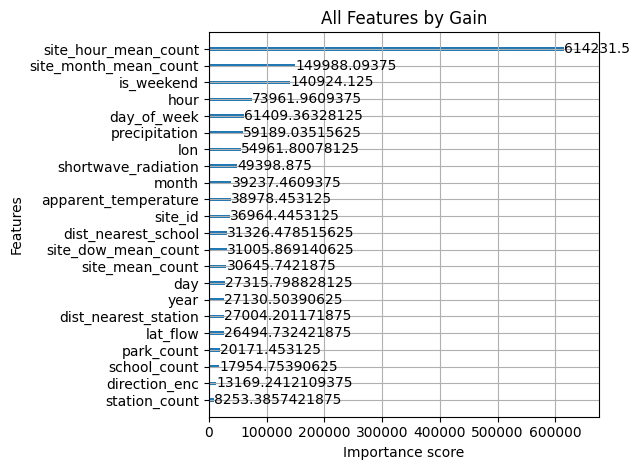

In [19]:
import matplotlib.pyplot as plt

xgb.plot_importance(final_model, max_num_features=None, importance_type="gain")
plt.title("All Features by Gain")
plt.tight_layout()
plt.show()

## Test set predictions for final model

In [34]:
PATH_PARQUET_TEST = "data/2025_forecast_integrated_data.parquet"
TEST_YEAR = 2025

In [35]:
test_df = pq.read_table(PATH_PARQUET_TEST, filters=[
            ("time", ">=", pd.Timestamp(f"{TEST_YEAR}-01-01")),
            ("time", "<=", pd.Timestamp(f"{TEST_YEAR}-12-31")),
        ],).to_pandas()
test_df

,site_id,direction,year,month,day,hour,lat_flow,lon,total_count,obs_per_hour,...,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description
0,1,in,2025,1,1,0,50.916183,4.456122,1.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
1,1,in,2025,1,1,1,50.916183,4.456122,1.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
2,1,in,2025,1,1,2,50.916183,4.456122,2.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
3,1,in,2025,1,1,3,50.916183,4.456122,1.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
4,1,in,2025,1,1,4,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2355380,143,out,2025,12,30,20,50.830662,3.262860,48.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
2355381,143,out,2025,12,30,21,50.830662,3.262860,35.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
2355382,143,out,2025,12,30,22,50.830662,3.262860,39.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
2355383,143,out,2025,12,30,23,50.830662,3.262860,31.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT


In [36]:
test_df["time"] = pd.to_datetime(test_df["time"])
test_df.set_index("time", inplace=True)

cols_to_drop = [
    "lat_meta", "long",
    "site_nr", "naam", "domein", "wegnr", "district", "gemeente", "description", "interval", "datum_van", # site metadata
    "snowfall", "rain", "relative_humidity_2m", "wind_speed_10m", "temperature_2m", "direct_normal_irradiance", "sunshine_duration" # weather features
]
test_df_clean = test_df.drop(columns=[c for c in cols_to_drop if c in test_df.columns], inplace=False)


test_df_clean["direction_enc"] = (test_df_clean["direction"] == "in").astype(int)  # 1=in  0=out
test_df_clean.drop(columns=["direction"], inplace=True)

test_df_clean["day_of_week"] = test_df_clean.index.dayofweek
test_df_clean["is_weekend"]  = (test_df_clean.index.dayofweek >= 5).astype(int)

test_df_clean.isna().sum()

site_id                      0
year                         0
month                        0
day                          0
hour                         0
lat_flow                     0
lon                          0
total_count                  0
obs_per_hour                 0
apparent_temperature         0
precipitation                0
shortwave_radiation          0
dist_nearest_station    570522
dist_nearest_school          0
school_count                 0
station_count                0
park_count                   0
direction_enc                0
day_of_week                  0
is_weekend                   0
dtype: int64

In [37]:
# ── Test windows from 2025-01-01 ──────────────────────────────────────────────
test_windows = {
    "1-day": ("2025-01-02", "2025-01-03"),
    "1-week)": ("2025-01-02", "2025-01-09"),
    "1-month": ("2025-01-02", "2025-02-01"),
}

for window_name, (start, end) in test_windows.items():
    window_df = test_df_clean[
        (test_df_clean.index >= start) &
        (test_df_clean.index <  end)
    ].copy()

    window_encoded = apply_encodings_final(window_df)
    X_window = window_encoded[FEATURES]
    y_window = window_encoded[TARGET]

    preds = np.clip(final_model.predict(X_window), 0, None)

    mae  = mean_absolute_error(y_window, preds)
    rmse = root_mean_squared_error(y_window, preds)
    r2   = r2_score(y_window, preds)
    mask = y_window > 0
    mape = np.mean(np.abs(y_window[mask] - preds[mask]) / y_window[mask]) * 100

    print(f"\nTest Window: {window_name} ({start} to {end})")
    print(f"Rows evaluated: {len(y_window):,}")

    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.1f}%  (non-zero counts only)")
    print(f"R²:   {r2:.3f}")


Test Window: 1-day (2025-01-02 to 2025-01-03)
Rows evaluated: 6,470
MAE:  3.02
RMSE: 8.12
MAPE: 68.9%  (non-zero counts only)
R²:   0.587

Test Window: 1-week) (2025-01-02 to 2025-01-09)
Rows evaluated: 45,148
MAE:  2.67
RMSE: 8.14
MAPE: 66.3%  (non-zero counts only)
R²:   0.789

Test Window: 1-month (2025-01-02 to 2025-02-01)
Rows evaluated: 193,780
MAE:  2.88
RMSE: 9.10
MAPE: 64.2%  (non-zero counts only)
R²:   0.791


In [38]:
def evaluate_all_sites(test_df_clean, final_model, apply_encodings_final,
                       FEATURES, TARGET, windows):

    all_results = []

    for start, end, window_name in windows:
        for site_id in sorted(test_df_clean["site_id"].unique()):
            for direction in test_df_clean["direction_enc"].unique(): 

                window_df = test_df_clean[
                    (test_df_clean.index >= start) &
                    (test_df_clean.index <  end) &
                    (test_df_clean["site_id"] == site_id) &
                    (test_df_clean["direction_enc"] == direction)
                ].copy()

                if len(window_df) == 0:
                    continue

                window_encoded = apply_encodings_final(window_df)
                X_window = window_encoded[FEATURES]
                y_window = window_encoded[TARGET]

                preds = np.clip(final_model.predict(X_window), 0, None)

                mae  = mean_absolute_error(y_window, preds)
                rmse = root_mean_squared_error(y_window, preds)
                r2   = r2_score(y_window, preds)
                mask = y_window > 0
                mape = np.mean(np.abs(y_window[mask] - preds[mask]) / y_window[mask]) * 100 if mask.sum() > 0 else np.nan

                all_results.append({
                    "site_id"    : site_id,
                    "window"     : window_name,
                    "MAE"        : round(mae, 2),
                    "RMSE"       : round(rmse, 2),
                    "MAPE"       : round(mape, 1),
                    "R2"         : round(r2, 3),
                    "n_rows"     : len(y_window),
                })

    return pd.DataFrame(all_results)


windows = [
    ("2025-01-01", "2025-01-02", "1-day"),
    ("2025-01-01", "2025-01-08", "1-week"),
    ("2025-01-01", "2025-02-01", "1-month"),
]

results_df = evaluate_all_sites(
    test_df_clean, final_model, apply_encodings_final, FEATURES, TARGET, windows
)

results_df

,site_id,window,MAE,RMSE,MAPE,R2,n_rows
0,1,1-day,3.50,4.51,290.899994,-23.639,24
1,1,1-day,3.28,4.77,286.799988,-12.704,24
2,2,1-day,12.69,15.95,409.399994,-13.665,24
3,2,1-day,1.77,2.74,72.300003,-0.595,24
4,3,1-day,0.41,0.63,76.400002,-0.582,24
...,...,...,...,...,...,...,...
803,139,1-month,1.66,2.96,76.099998,0.330,744
804,140,1-month,7.11,11.36,51.500000,0.836,744
805,140,1-month,8.81,14.39,52.700001,0.811,744
806,143,1-month,15.84,26.82,40.700001,0.885,744


In [39]:
results_df.to_csv("data/per_site_metrics_forecast_data.csv", index=False)

In [41]:
historical_results_df = pd.read_csv("data/per_site_metrics_historical_data.csv")
forecast_results_df = pd.read_csv("data/per_site_metrics_forecast_data.csv")

In [48]:
historical_results_df[historical_results_df["window"] == "1-month"].sort_values("MAE")

,site_id,window,MAE,RMSE,MAPE,R2,n_rows
592,28,1-month,0.09,0.26,94.400002,-0.663,744
743,105,1-month,0.10,0.24,NaN,0.000,744
657,60,1-month,0.12,0.33,89.300003,-0.459,744
605,34,1-month,0.13,0.33,86.300003,-0.453,744
673,68,1-month,0.13,0.34,94.300003,-0.651,744
...,...,...,...,...,...,...,...
806,143,1-month,15.66,26.30,40.799999,0.890,744
746,107,1-month,16.42,24.51,42.200001,0.893,744
747,107,1-month,19.35,32.17,43.099998,0.779,744
777,125,1-month,30.05,61.92,88.400002,-0.151,744


In [ ]:
forecast_results_df[forecast_results_df["window"] == "1-month"].sort_values("MAE")

,site_id,window,MAE,RMSE,MAPE,R2,n_rows
592,28,1-month,0.08,0.25,95.599998,-0.576,744
743,105,1-month,0.09,0.23,NaN,0.000,744
657,60,1-month,0.13,0.34,88.800003,-0.556,744
605,34,1-month,0.13,0.32,88.800003,-0.400,744
673,68,1-month,0.13,0.33,95.300003,-0.633,744
...,...,...,...,...,...,...,...
806,143,1-month,15.84,26.82,40.700001,0.885,744
746,107,1-month,16.60,24.81,44.200001,0.891,744
747,107,1-month,19.12,32.00,42.900002,0.781,744
777,125,1-month,30.07,61.95,88.599998,-0.152,744


In [44]:
historical_results_df.groupby("window").agg({"MAE": "mean", "RMSE": "mean", "MAPE": "mean", "R2": "mean", "n_rows": "sum"}).reset_index()

,window,MAE,RMSE,MAPE,R2,n_rows
0,1-day,3.854813,5.738134,190.933864,-78.505470,6422
1,1-month,2.917407,5.226889,88.029104,-438.401293,200202
2,1-week,2.785481,4.804926,101.423880,-163.993093,45186


In [45]:
forecast_results_df.groupby("window").agg({"MAE": "mean", "RMSE": "mean", "MAPE": "mean", "R2": "mean", "n_rows": "sum"}).reset_index()


,window,MAE,RMSE,MAPE,R2,n_rows
0,1-day,3.995746,5.980299,194.788447,-102.624007,6422
1,1-month,2.914037,5.243074,87.140299,-421.746833,200202
2,1-week,2.802407,4.900556,99.842911,-176.839937,45186


In [ ]:
# def plot_site_forecast(test_df_clean, final_model, apply_encodings_final,
#                        FEATURES, TARGET, start, end, window_name, site_id, direction=None):

#     window_df = test_df_clean[
#         (test_df_clean.index >= start) &
#         (test_df_clean.index <  end) &
#         (test_df_clean["site_id"] == site_id)
#     ].copy()

#     if direction is not None:
#         window_df = window_df[window_df["direction_enc"] == direction]

#     if len(window_df) == 0:
#         print(f"No data for site {site_id} in {window_name}")
#         return

#     window_encoded = apply_encodings_final(window_df)
#     X_window = window_encoded[FEATURES]
#     y_window = window_encoded[TARGET]

#     preds = pd.Series(
#         np.clip(final_model.predict(X_window), 0, None),
#         index=y_window.index
#     )

#     # Pull metrics from results_df
#     row = results_df[
#         (results_df["site_id"] == site_id) &
#         (results_df["window"]  == window_name)
#     ]
#     metrics_text = f"MAE: {row['MAE'].values[0]}  |  RMSE: {row['RMSE'].values[0]}  |  MAPE: {row['MAPE'].values[0]}%  |  R²: {row['R2'].values[0]}"

#     # Aggregation
#     if window_name == "1-day":
#         actual    = y_window.resample("h").sum()
#         predicted = preds.resample("h").sum()
#         xlabel    = "Hour"
#         fmt       = mdates.HourLocator(interval=2)
#         date_fmt  = mdates.DateFormatter("%H:%M")
#     else:
#         actual    = y_window.resample("D").sum()
#         predicted = preds.resample("D").sum()
#         xlabel    = "Date"
#         fmt       = mdates.DayLocator(interval=1) if window_name == "1-week" else mdates.WeekdayLocator(interval=1)
#         date_fmt  = mdates.DateFormatter("%b %d")

#     dir_label = {None: "All directions", 1: "IN", 0: "OUT"}.get(direction, "")
#     title = f"Forecast vs Actual — Site {site_id} ({dir_label}) — {window_name}"

#     fig, ax = plt.subplots(figsize=(12, 4))
#     ax.plot(actual.index, actual.values,
#             color="#4C72B0", linewidth=1.5, label="Actual")
#     ax.plot(predicted.index, predicted.values,
#             color="#C44E52", linewidth=1.5, linestyle="--", label="Forecast")
#     ax.text(0.01, 0.97, metrics_text, transform=ax.transAxes, fontsize=9,
#             verticalalignment="top",
#             bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
#     ax.xaxis.set_major_locator(fmt)
#     ax.xaxis.set_major_formatter(date_fmt)
#     plt.xticks(rotation=45)
#     ax.set_title(title, fontsize=13)
#     ax.set_xlabel(xlabel)
#     ax.set_ylabel("Cyclist Count")
#     ax.legend()
#     ax.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(f"forecast_site{site_id}_{direction}_{window_name}.png", dpi=150)
#     plt.show()


# # ── Usage: pick your site and direction ───────────────────────────────────────
# plot_site_forecast(test_df_clean, final_model, apply_encodings_final,
#                    FEATURES, TARGET, "2025-01-01", "2025-01-02", "1-day",
#                    site_id=1, direction=1)       # site 1, IN direction

# plot_site_forecast(test_df_clean, final_model, apply_encodings_final,
#                    FEATURES, TARGET, "2025-01-01", "2025-01-08", "1-week",
#                    site_id=1, direction=None)    # site 1, both directions

# plot_site_forecast(test_df_clean, final_model, apply_encodings_final,
#                    FEATURES, TARGET, "2025-01-01", "2025-02-01", "1-month",
#                    site_id=28, direction=0)      # site 28, OUT direction